In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
customer_segment=pd.read_csv('/content/Test.csv')
customer_segment.head(11)

,ID,Gender,Ever_Married,Age,Graduated,Profession,Work_Experience,Spending_Score,Family_Size,Var_1
0,458989,Female,Yes,36,Yes,Engineer,0.0,Low,1.0,Cat_6
1,458994,Male,Yes,37,Yes,Healthcare,8.0,Average,4.0,Cat_6
2,458996,Female,Yes,69,No,NaN,0.0,Low,1.0,Cat_6
3,459000,Male,Yes,59,No,Executive,11.0,High,2.0,Cat_6
4,459001,Female,No,19,No,Marketing,NaN,Low,4.0,Cat_6
5,459003,Male,Yes,47,Yes,Doctor,0.0,High,5.0,Cat_4
6,459005,Male,Yes,61,Yes,Doctor,5.0,Low,3.0,Cat_6
7,459008,Female,Yes,47,Yes,Artist,1.0,Average,3.0,Cat_6
8,459013,Male,Yes,50,Yes,Artist,2.0,Average,4.0,Cat_6
9,459014,Male,No,19,No,Healthcare,0.0,Low,4.0,Cat_6


In [6]:
customer_segment=customer_segment.drop(['ID'],axis=1)
customer_segment.head(6)

,Gender,Ever_Married,Age,Graduated,Profession,Work_Experience,Spending_Score,Family_Size,Var_1
0,Female,Yes,36,Yes,Engineer,0.0,Low,1.0,Cat_6
1,Male,Yes,37,Yes,Healthcare,8.0,Average,4.0,Cat_6
2,Female,Yes,69,No,NaN,0.0,Low,1.0,Cat_6
3,Male,Yes,59,No,Executive,11.0,High,2.0,Cat_6
4,Female,No,19,No,Marketing,NaN,Low,4.0,Cat_6
5,Male,Yes,47,Yes,Doctor,0.0,High,5.0,Cat_4


In [7]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

In [19]:
x=customer_segment[['Age','Family_Size']]
scalar=StandardScaler()
x_scaled=scalar.fit_transform(x)

In [27]:
nan_rows = np.isnan(x_scaled).any(axis=1)
x_scaled_cleaned = x_scaled[~nan_rows]

kmeans=KMeans(n_clusters=5,random_state=42)
clusters=kmeans.fit_predict(x_scaled_cleaned)

In [30]:
KMeans(n_clusters=5,random_state=42)

KMeans(n_clusters=5, random_state=42)

In [31]:
centroids=kmeans.cluster_centers_

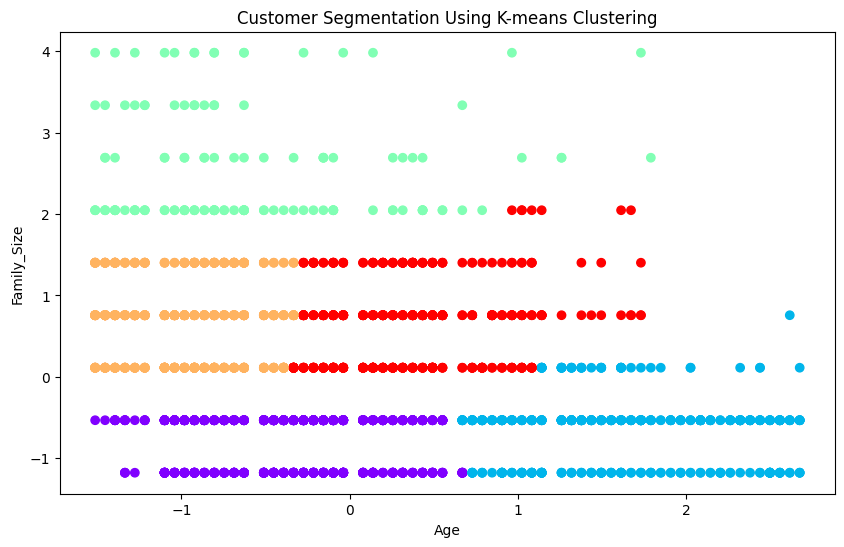

In [33]:
plt.figure(figsize=(10,6))
plt.scatter(x_scaled_cleaned[:,0],x_scaled_cleaned[:,1],c=clusters,cmap='rainbow')
plt.xlabel('Age')
plt.ylabel('Family_Size')
plt.title('Customer Segmentation Using K-means Clustering')
plt.show()

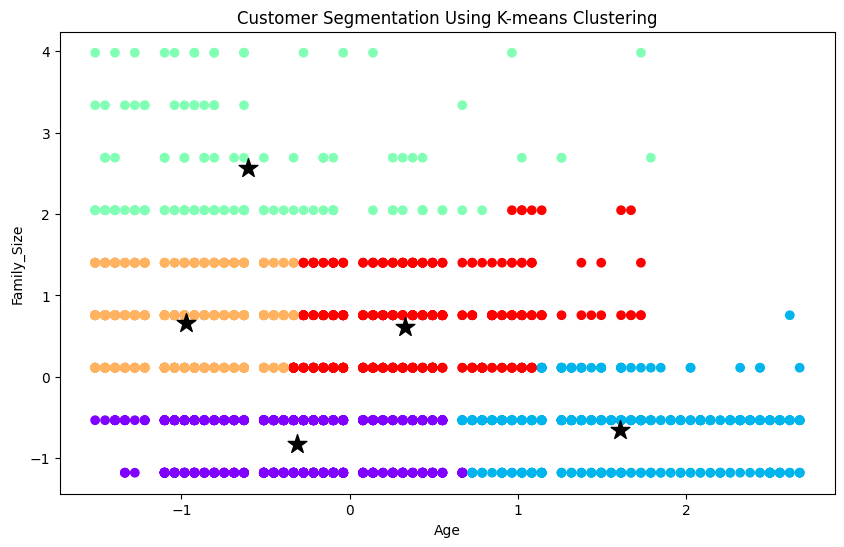

               Age  Family_Size
cluster                        
0        38.339141     1.552846
1        70.872294     1.820346
2        33.414062     6.812500
3        27.126761     3.850352
4        49.210101     3.769697


In [35]:
plt.figure(figsize=(10,6))
plt.scatter(x_scaled_cleaned[:,0],x_scaled_cleaned[:,1],c=clusters,cmap='rainbow')
plt.scatter(centroids[:,0],centroids[:,1],marker='*',s=200,color='black')
plt.xlabel('Age')
plt.ylabel('Family_Size')
plt.title('Customer Segmentation Using K-means Clustering')
plt.show()

# Filter customer_segment to match the cleaned scaled data and add the cluster column
customer_segment_cleaned = customer_segment[~nan_rows].copy()
customer_segment_cleaned['cluster'] = clusters
cluster_summary=customer_segment_cleaned.groupby('cluster')[['Age','Family_Size']].mean()
print(cluster_summary)